# 03: Spectral Domain, Filterbanks & Vocoder Artifact Forensics

## 1. Research Scope & Objectives
This notebook evaluates spectral representations (STFT, Log-Mel Filterbanks, Welch PSD), higher-order spectral moments, spectral flatness, crest factor, and neural vocoder high-frequency cutoff/bandgap artifacts.

### Mathematical Formulations
Short-Time Fourier Transform:
$$X(k, m) = \sum_{n=0}^{N-1} x[m \cdot H + n] w[n] e^{-j \frac{2\pi}{N} k n}, \quad S(k, m) = |X(k, m)|^2$$
Spectral Centroid & Rolloff:
$$\mu_1 = \frac{\sum_k f_k S(k)}{\sum_k S(k)}, \quad \sum_{k=0}^{k_{\text{roll}}} S(k) = 0.85 \sum_k S(k)$$
Spectral Flatness (Wiener Entropy):
$$\text{SF} = \frac{\exp\left(\frac{1}{K}\sum_{k=1}^K \ln S(k)\right)}{\frac{1}{K}\sum_{k=1}^K S(k)}$$

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

import soundfile as sf, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, librosa
from src.utils.config import path_config

sns.set_theme(style="whitegrid")
manifest_path = os.path.join(path_config.data_processed, "protocol_manifest.parquet")
df = pd.read_parquet(manifest_path)

## 2. High-Resolution STFT Spectrogram Forensics

In [2]:
sample_bon = df[df.key == "bonafide"].iloc[0]["file_path"]
sample_a01 = df[(df.key == "spoof") & (df.attack_id == "A01")].iloc[0]["file_path"]
sample_a02 = df[(df.key == "spoof") & (df.attack_id == "A02")].iloc[0]["file_path"]

y_b, sr = sf.read(sample_bon)
y_1, _ = sf.read(sample_a01)
y_2, _ = sf.read(sample_a02)

S_b_db = librosa.amplitude_to_db(np.abs(librosa.stft(y_b, n_fft=1024, hop_length=256)), ref=np.max)
S_1_db = librosa.amplitude_to_db(np.abs(librosa.stft(y_1, n_fft=1024, hop_length=256)), ref=np.max)
S_2_db = librosa.amplitude_to_db(np.abs(librosa.stft(y_2, n_fft=1024, hop_length=256)), ref=np.max)

c:\Users\tamimystic\.conda\envs\ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


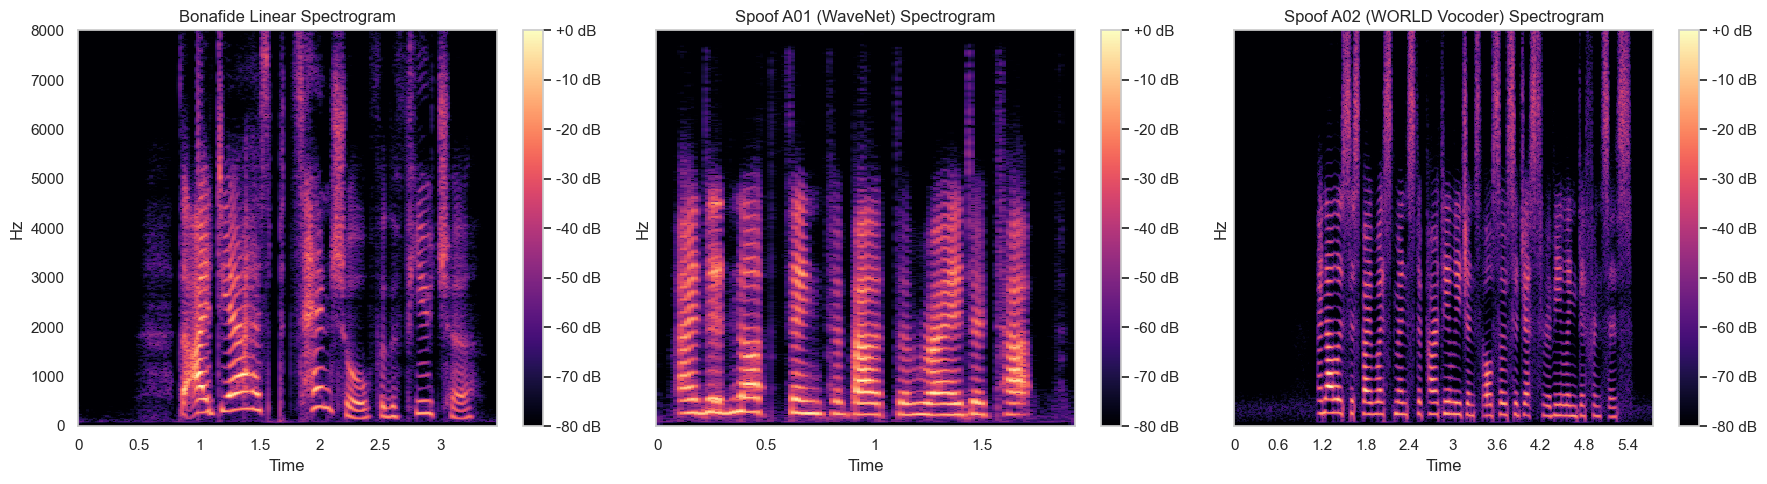

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
im1 = librosa.display.specshow(S_b_db, sr=sr, hop_length=256, x_axis="time", y_axis="linear", ax=axes[0], cmap="magma")
axes[0].set_title("Bonafide Linear Spectrogram")
fig.colorbar(im1, ax=axes[0], format="%+2.0f dB")

im2 = librosa.display.specshow(S_1_db, sr=sr, hop_length=256, x_axis="time", y_axis="linear", ax=axes[1], cmap="magma")
axes[1].set_title("Spoof A01 (WaveNet) Spectrogram")
fig.colorbar(im2, ax=axes[1], format="%+2.0f dB")

im3 = librosa.display.specshow(S_2_db, sr=sr, hop_length=256, x_axis="time", y_axis="linear", ax=axes[2], cmap="magma")
axes[2].set_title("Spoof A02 (WORLD Vocoder) Spectrogram")
fig.colorbar(im3, ax=axes[2], format="%+2.0f dB")
plt.tight_layout()
plt.show()

## 3. Log-Mel Filterbank Transformations (80 vs 128 Channels)

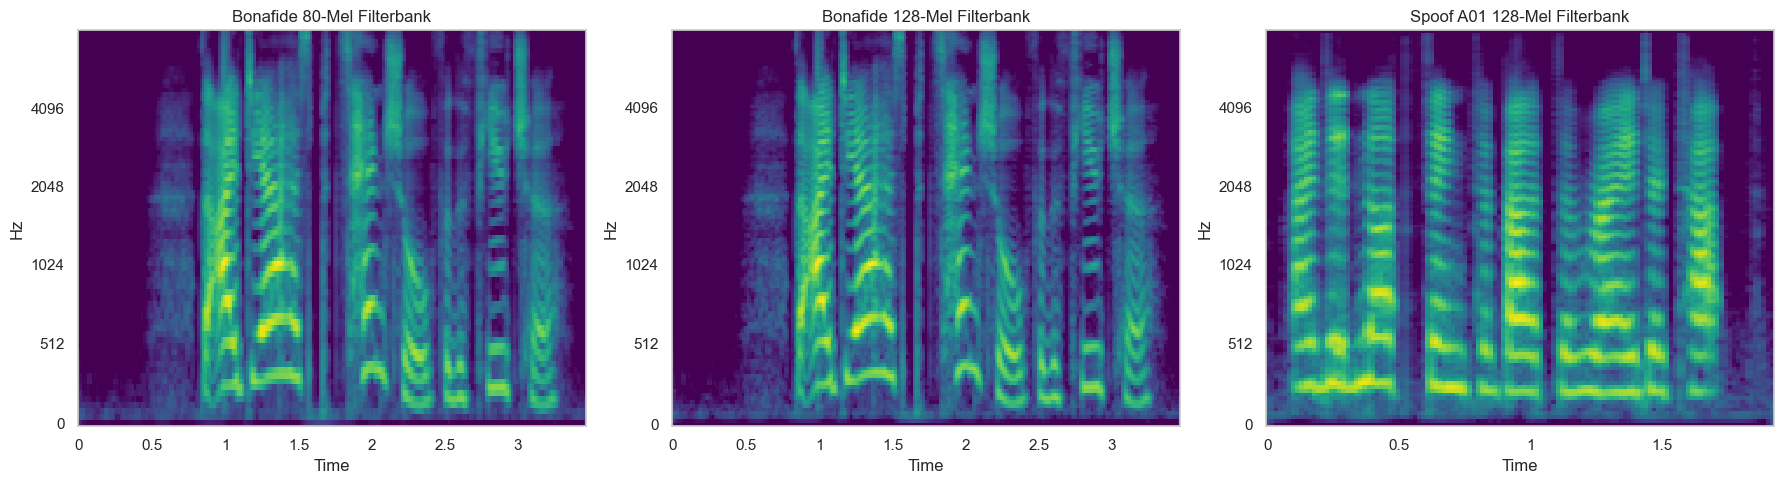

In [4]:
mel_b_80 = librosa.power_to_db(librosa.feature.melspectrogram(y=y_b, sr=sr, n_fft=1024, hop_length=256, n_mels=80), ref=np.max)
mel_b_128 = librosa.power_to_db(librosa.feature.melspectrogram(y=y_b, sr=sr, n_fft=1024, hop_length=256, n_mels=128), ref=np.max)
mel_1_128 = librosa.power_to_db(librosa.feature.melspectrogram(y=y_1, sr=sr, n_fft=1024, hop_length=256, n_mels=128), ref=np.max)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
librosa.display.specshow(mel_b_80, sr=sr, hop_length=256, x_axis="time", y_axis="mel", ax=axes[0], cmap="viridis")
axes[0].set_title("Bonafide 80-Mel Filterbank")

librosa.display.specshow(mel_b_128, sr=sr, hop_length=256, x_axis="time", y_axis="mel", ax=axes[1], cmap="viridis")
axes[1].set_title("Bonafide 128-Mel Filterbank")

librosa.display.specshow(mel_1_128, sr=sr, hop_length=256, x_axis="time", y_axis="mel", ax=axes[2], cmap="viridis")
axes[2].set_title("Spoof A01 128-Mel Filterbank")
plt.tight_layout()
plt.show()

## 4. Higher-Order Spectral Descriptors & Moments

In [5]:
def extract_spectral_moments(file_paths):
    records = []
    for p in file_paths:
        y, sr = sf.read(p)
        cent = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
        roll = librosa.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85)[0]
        flat = librosa.feature.spectral_flatness(y=y)[0]
        records.append({
            "centroid_mean": np.mean(cent),
            "centroid_std": np.std(cent),
            "rolloff_mean": np.mean(roll),
            "flatness_mean": np.mean(flat)
        })
    return pd.DataFrame(records)

bon_p = df[(df.split=="train") & (df.key=="bonafide")]["file_path"].head(80)
spf_p = df[(df.split=="train") & (df.key=="spoof")]["file_path"].head(80)

bon_spec = extract_spectral_moments(bon_p)
bon_spec["key"] = "bonafide"
spf_spec = extract_spectral_moments(spf_p)
spf_spec["key"] = "spoof"
spec_df = pd.concat([bon_spec, spf_spec], ignore_index=True)

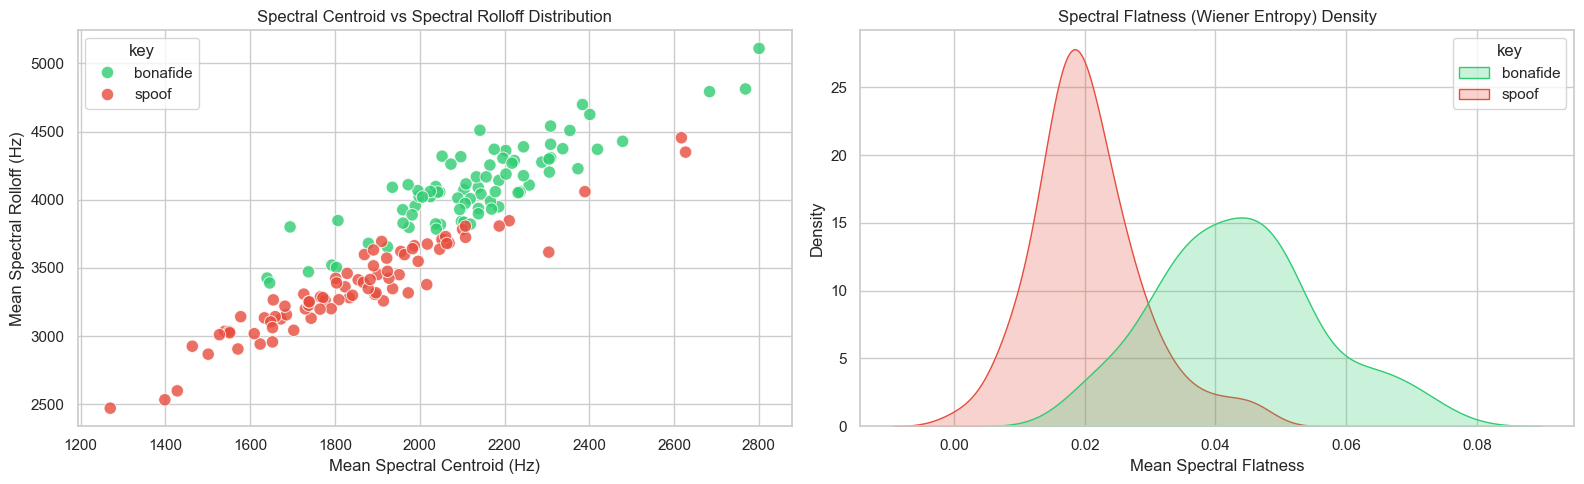

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.scatterplot(data=spec_df, x="centroid_mean", y="rolloff_mean", hue="key", palette=["#2ecc71", "#e74c3c"], s=80, alpha=0.8, ax=axes[0])
axes[0].set_title("Spectral Centroid vs Spectral Rolloff Distribution")
axes[0].set_xlabel("Mean Spectral Centroid (Hz)")
axes[0].set_ylabel("Mean Spectral Rolloff (Hz)")

sns.kdeplot(data=spec_df, x="flatness_mean", hue="key", fill=True, palette=["#2ecc71", "#e74c3c"], ax=axes[1])
axes[1].set_title("Spectral Flatness (Wiener Entropy) Density")
axes[1].set_xlabel("Mean Spectral Flatness")
plt.tight_layout()
plt.show()

## 5. Neural Vocoder High-Frequency Bandgap Forensics
Neural upsampling layers frequently introduce sharp energy cutoffs near 4 kHz and 8 kHz.

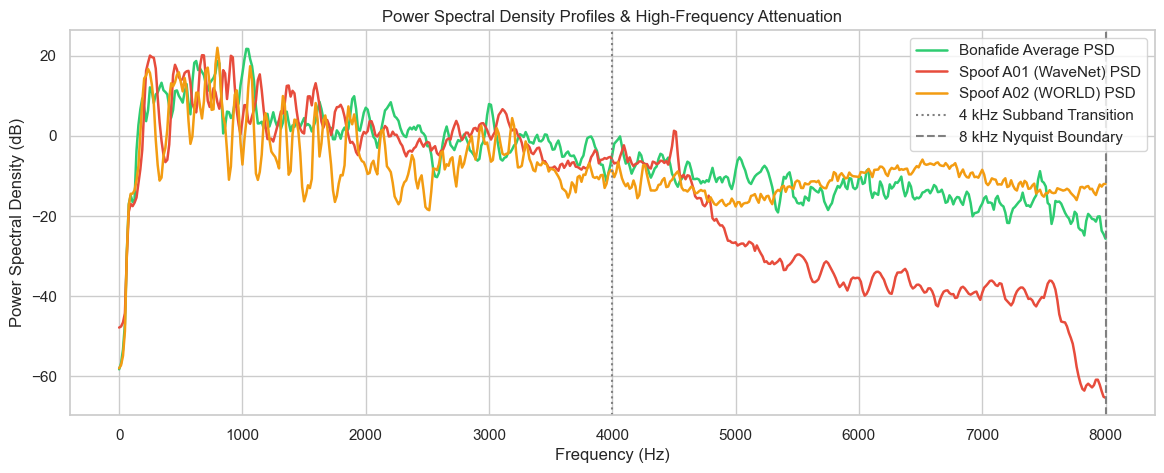

In [7]:
freqs = librosa.fft_frequencies(sr=sr, n_fft=1024)
psd_b = np.mean(np.abs(librosa.stft(y_b, n_fft=1024, hop_length=256))**2, axis=1)
psd_1 = np.mean(np.abs(librosa.stft(y_1, n_fft=1024, hop_length=256))**2, axis=1)
psd_2 = np.mean(np.abs(librosa.stft(y_2, n_fft=1024, hop_length=256))**2, axis=1)

plt.figure(figsize=(14, 5))
plt.plot(freqs, 10*np.log10(psd_b + 1e-9), label="Bonafide Average PSD", color="#2ecc71", lw=1.8)
plt.plot(freqs, 10*np.log10(psd_1 + 1e-9), label="Spoof A01 (WaveNet) PSD", color="#e74c3c", lw=1.8)
plt.plot(freqs, 10*np.log10(psd_2 + 1e-9), label="Spoof A02 (WORLD) PSD", color="#f39c12", lw=1.8)
plt.axvline(x=4000, color="gray", ls=":", label="4 kHz Subband Transition")
plt.axvline(x=8000, color="gray", ls="--", label="8 kHz Nyquist Boundary")
plt.title("Power Spectral Density Profiles & High-Frequency Attenuation")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (dB)")
plt.legend()
plt.show()